In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
import dgl
from dgl.dataloading import GraphDataLoader
from torch.utils.data import Subset
from sklearn.model_selection import KFold
from scipy.stats import kendalltau, spearmanr
from sklearn.metrics import mean_squared_error, mean_absolute_error, confusion_matrix, roc_curve, auc, r2_score
import optuna
from datetime import datetime
import os
import numpy
import random
import math
from tqdm.auto import tqdm
import pandas as pd
from prettytable import PrettyTable
from rdkit import Chem
from rdkit.Chem import MACCSkeys
from rdkit.Avalon import pyAvalonTools
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator
from torch.optim.lr_scheduler import _LRScheduler
from dgl.data import DGLDataset
from dgl.nn.pytorch.glob import SumPooling
import dgl.function as fn
from io import StringIO
import numpy as np
import warnings

# --- 환경 설정 ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
seed = 19990323

/home/minji/anaconda3/envs/oadmet_expansion_demo/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


In [2]:
def set_random_seed(seed=0):
    dgl.seed(seed)
    random.seed(seed)
    numpy.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f'RANDOM, DGL, NUMPY and TORCH random seed is set {seed}.')
set_random_seed(seed)

# 9개 ADMET 속성 컬럼 이름 (Log 변환된 결과)
MULTI_REG_LABEL_COLS = [
    'LogD', 'LogS', 'Log_HLM_CLint', 'Log_MLM_CLint', 'Log_Caco_Papp_AB', 
    'Log_Caco_ER', 'Log_Mouse_PPB', 'Log_Mouse_BPB', 'Log_Mouse_MPB'
]
NUM_OUTPUTS = len(MULTI_REG_LABEL_COLS) # 9


# --- 평가 지표 함수 ---
def analysis_regression(pred, true):
    # (이전에 제공한 analysis_regression 함수와 동일)
    mae = mean_absolute_error( true, pred )
    mse = mean_squared_error ( true, pred )
    rmse = mse ** 0.5
    kendall  = kendalltau(true, pred)[0]
    spearman = spearmanr(true, pred)[0]
    corrcoef = numpy.corrcoef(true, pred)[0][1]
    r2 = r2_score( true, pred )

    result = {
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R^2": r2,
        "Kendall Tau": kendall,
        "Spearman R": spearman,
        "Pearson R": corrcoef,
    }
    return result

def analysis_table(dct, type='float'):
    table = PrettyTable()
    for c in dct.keys():
        table.add_column(c, [])
    if type == 'int':
        table.add_row([ f'{int(c)}' for c in dct.values()])
    else:
        table.add_row([ f'{float(c):.3f}' for c in dct.values()])
    print(table)
    return table

# --- MA-RAE 평가 지표 함수 (대회 기준) ---
def calculate_ma_rae(pred_matrix, true_matrix, nan_mask):
    """ Macro-Averaged Relative Absolute Error (MA-RAE) 계산 """
    num_tasks = true_matrix.shape[1]
    rae_list = []
    
    for i in range(num_tasks):
        true_i = true_matrix[nan_mask[:, i], i]
        pred_i = pred_matrix[nan_mask[:, i], i]
        
        if len(true_i) == 0: continue
            
        numerator = np.sum(np.abs(pred_i - true_i))
        denominator = np.sum(np.abs(true_i - np.mean(true_i)))
        
        rae = numerator / denominator if denominator != 0 else 1.0
        rae_list.append(rae)
        
    return np.mean(rae_list) if len(rae_list) > 0 else 100.0

def masked_mse_loss(outputs, labels):
    """ Loss 계산 시 labels 내의 NaN 값을 마스킹하고 유효한 값들로만 MSE를 계산 """
    # labels의 NaN 값을 마스킹합니다. (True = 유효한 값)
    mask = ~torch.isnan(labels)
    
    # 배치에 유효한 Loss를 계산할 데이터 포인트가 하나도 없는 경우 (매우 드묾)
    # requires_grad=True를 통해 역전파 가능하게 0.0을 반환
    if mask.sum() == 0:
        return torch.tensor(0.0, device=outputs.device, requires_grad=True)

    # 유효한 값들만 선택하여 평균 MSE를 계산합니다.
    return F.mse_loss(outputs[mask], labels[mask], reduction='mean')

def analysis_multi_reg(pred_matrix, true_matrix):
    """ Multi-Task 평가 지표 계산 """
    nan_mask = ~np.isnan(true_matrix)
    ma_rae = calculate_ma_rae(pred_matrix, true_matrix, nan_mask)
    
    maes = []
    r2s = []
    for i in range(NUM_OUTPUTS):
        true_i = true_matrix[nan_mask[:, i], i]
        pred_i = pred_matrix[nan_mask[:, i], i]
        
        if len(true_i) > 0:
            maes.append(mean_absolute_error(true_i, pred_i))
            r2s.append(r2_score(true_i, pred_i))

    result = {
        "MA-RAE": ma_rae,
        "Macro-MAE": np.mean(maes) if maes else np.nan,
        "Macro-R^2": np.mean(r2s) if r2s else np.nan,
    }
    return result

# DGL 그래프 배칭을 위한 collate 함수 정의
def collate(samples):
    # samples는 (graph, label, (fp1, fp2, fp3)) 튜플의 리스트입니다.
    graphs, labels, fps_tuple = map(list, zip(*samples))
    
    # DGL의 batch API를 사용하여 그래프들을 배치로 묶음
    batched_graph = dgl.batch(graphs)
    
    # labels를 배치로 묶음
    batched_labels = torch.stack(labels)
    
    # 각 지문(Fingerprint) 종류별로 배치로 묶음
    fp1 = torch.stack([f[0] for f in fps_tuple])
    fp2 = torch.stack([f[1] for f in fps_tuple])
    fp3 = torch.stack([f[2] for f in fps_tuple])
    batched_fps = (fp1, fp2, fp3)
    
    return batched_graph, batched_labels, batched_fps

RANDOM, DGL, NUMPY and TORCH random seed is set 19990323.


In [3]:
# --- 분자 Feature 추출 함수 ---
def one_hot(x, allowable_set):
    if x not in set(allowable_set):
        x = allowable_set[-1]
    return [x == s for s in allowable_set]

METAL =["LI","NA","K","RB","CS","MG","TL","CU","AG","BE","NI","PT","ZN","CO",
        "PD","AG","CR","FE","V","MN","HG",'GA',"CD","YB","CA","SN","PB","EU",
        "SR","SM","BA","RA","AL","IN","TL","Y","LA","CE","PR","ND","GD","TB",
        "DY","ER","TM","LU","HF","ZR","CE","U","PU","TH","AU"] 

PERIODIC_table = '''H  __ __ __ __ __ __ __ __ __ __ __ __ __ __ __ __ He
Li Be __ __ __ __ __ __ __ __ __ __ B  C  N  O  F  Ne
Na Mg __ __ __ __ __ __ __ __ __ __ Al Si P  S  Cl Ar
K  Ca Sc Ti V  Cr Mn Fe Co Ni Cu Zn Ga Ge As Se Br Kr
Rb Sr Y  Zr Nb Mo Tc Ru Rh Pd Ag Cd In Sn Sb Te I  Xe'''

PERIODIC = {}
for i, per in enumerate(PERIODIC_table.split('\n')):
    for j, atom in enumerate(per.split()):
        if atom != '__':
            PERIODIC[atom] = (i, j)

electronegativity_table = '''2.20 ____ ____ ____ ____ ____ ____ ____ ____ ____ ____ ____ ____ ____ ____ ____ ____ ____
0.98 1.57 ____ ____ ____ ____ ____ ____ ____ ____ ____ ____ 2.04 2.55 3.04 3.44 3.98 ____
0.93 1.31 ____ ____ ____ ____ ____ ____ ____ ____ ____ ____ 1.61 1.90 2.19 2.58 3.16 ____
0.82 1.00 1.36 1.54 1.63 1.66 1.55 1.83 1.88 1.91 1.90 1.65 1.81 2.01 2.18 2.55 2.96 3.00
0.82 0.95 1.22 1.33 1.60 2.16 1.90 2.20 2.28 2.20 1.93 1.69 1.78 1.96 2.05 2.10 2.66 2.60'''

ELECTRONEGATIVITY = {}
for i, per in enumerate(electronegativity_table.split('\n')):
    for j, atom_electronegativity in enumerate(per.split()):
        if atom_electronegativity != '____':
            ELECTRONEGATIVITY[(i, j)] = float(atom_electronegativity)

allowable_atom    = ['C', 'N', 'O', 'S', 'P', 'F', 'Cl', 'Br', 'I', 'UNK']
allowable_period  = [ i for i in range(5) ]
allowable_group   = [ i for i in range(18) ]
allowable_degree  = [ i for i in range(7) ]
allowable_totalHs = [ i for i in range(5) ]
allowable_hybrid  = [ Chem.rdchem.HybridizationType.SP,
                      Chem.rdchem.HybridizationType.SP2,
                      Chem.rdchem.HybridizationType.SP3,
                      Chem.rdchem.HybridizationType.SP3D,
                      Chem.rdchem.HybridizationType.SP3D2,
                      Chem.rdchem.HybridizationType.UNSPECIFIED ]
allowable_bond = [ Chem.rdchem.BondType.SINGLE,
                  Chem.rdchem.BondType.DOUBLE,
                  Chem.rdchem.BondType.TRIPLE,
                  Chem.rdchem.BondType.AROMATIC ]
allowable_streo = [ Chem.rdchem.BondStereo.STEREOANY,
                    Chem.rdchem.BondStereo.STEREOCIS,
                    Chem.rdchem.BondStereo.STEREOE,
                    Chem.rdchem.BondStereo.STEREONONE,
                    Chem.rdchem.BondStereo.STEREOTRANS,
                    Chem.rdchem.BondStereo.STEREOZ ]

def atom_feature(atom):
    symbol = atom.GetSymbol()
    period, group = PERIODIC.get(symbol, (5, 18))
    negativity = [ELECTRONEGATIVITY.get((period, group), 0.0)]
    return (
        one_hot(symbol, allowable_atom) +
        one_hot(period, allowable_period) +
        one_hot(group, allowable_group) +
        one_hot(atom.GetDegree(), allowable_degree) +
        one_hot(atom.GetTotalNumHs(), allowable_totalHs) +
        one_hot(atom.GetHybridization(), allowable_hybrid) +
        [atom.GetIsAromatic(), atom.IsInRing(), atom.GetNumRadicalElectrons(), atom.GetFormalCharge() / 5] +
        negativity
    )

def get_smarts_match(mol, smarts):
    return torch.as_tensor( mol.GetSubstructMatches(Chem.MolFromSmarts(smarts) ) )

def get_atom_smarts_feature(mol, smarts_patterns):
    smart_feature = torch.zeros( mol.GetNumAtoms(), len(smarts_patterns) ) 
    for idx, smarts in enumerate( smarts_patterns.values() ):
        select_indices = get_smarts_match( mol, smarts )
        if select_indices.numel() == 0:
            continue
        smart_feature[select_indices, idx] += 1
    return smart_feature

def get_molecule_atom_feature(mol):
    atomic_smarts_patterns = {
        "hydrogen_accept": "[$([O,S;H1;v2;!$(*-*=[O,N,P,S])]),$([O,S;H0;v2]),$([O,S;-]),$([N;v3;!$(N-*=[O,N,P,S])]),n&H0&+0,$([o,s;+0;!$([o,s]:n);!$([o,s]:c:n)])]",
        "hydrogen_donor": "[$([N;!H0;v3,v4&+1]),$([O,S;H1;+0]),n&H1&+0]",
        "electron_accept": "[$([C,S](=[O,S,P])-[O;H1,-1])]",
        "electron_donor": "[#7;+,$([N;H2&+0][$([C,a]);!$([C,a](=O))]),$([N;H1&+0]([$([C,a]);!$([C,a](=O))])[$([C,a]);!$([C,a](=O))]),$([N;H0&+0]([C;!$(C(=O))])([C;!$(C(=O))])[C;!$(C(=O))])]",
        "hydrophobic": "[C,c,S&H0&v2,F,Cl,Br,I&!$(C=[O,N,P,S])&!$(C#N);!$(C=O)]"
    }

    af = torch.as_tensor([atom_feature(atom) for atom in mol.GetAtoms()])
    sf = get_atom_smarts_feature( mol, atomic_smarts_patterns )

    feature = torch.cat( (af, sf), dim=-1).float()

    return feature

def bond_feature(bond):
    return (one_hot(bond.GetBondType(), allowable_bond) +
            one_hot(bond.GetStereo(), allowable_streo) +
            [bond.IsInRing(), bond.GetIsConjugated()])

def get_molecule_bond_feature(mol):
    adj = torch.zeros( ( mol.GetNumAtoms(), mol.GetNumAtoms(), 13 ) )

    rotate_smarts = "[!$(*#*)&!D1]-!@[!$(*#*)&!D1]"
    rotate = get_smarts_match( mol, rotate_smarts )

    bond_atom_indices =  torch.triu( torch.tensor( Chem.GetAdjacencyMatrix(mol) ) ).nonzero()

    for bond_atom_index in bond_atom_indices:
        src = bond_atom_index[0].item()
        dst = bond_atom_index[1].item()
        bond = mol.GetBondBetweenAtoms( src, dst )
        if rotate.numel() == 0:
            adj[src, dst] = torch.tensor( bond_feature(bond) + [False] )
        else:
            adj[src, dst] = torch.tensor( bond_feature(bond) + [ bond_atom_index in rotate ] )

    adj += torch.transpose_copy( adj, 0, 1 )

    return adj

In [4]:
# --- Dataset 클래스 (9개 레이블 로드하도록 수정) ---
class MoleculeDataset(DGLDataset):
    def __init__(self, df, label_cols, pos_dim=20):
        super(MoleculeDataset, self).__init__(name='Molecule dataset')

        self.graphs = []
        self.labels = []
        self.fps = []

        # label_cols을 사용하여 9개 레이블을 모두 로드
        for _, row in tqdm(df.iterrows(), total=len(df)):
            smiles = row['SMILES']
            
            # -----------------------------------------------------------------
            # ★★★ 수정된 부분: NumPy 배열 생성 시 float64로 강제 변환 적용 ★★★
            # 'row[label_cols].values'가 object 타입인 문제를 해결합니다.
            true = torch.as_tensor(row[label_cols].values.astype(np.float64)).float()
            # -----------------------------------------------------------------
            
            smiles = max( smiles.split('.'), key=len)
            mol = Chem.MolFromSmiles( smiles )
            if mol == None:
                continue
            fps = self.get_fps( mol )

            if mol.GetNumAtoms() == 1:
                atom_feat = get_molecule_atom_feature(mol)
                g = dgl.DGLGraph()
                g.add_nodes(1)
                g.ndata['feat'] = atom_feat
                self.get_rwpe( g )

            else:
                atom_feat = get_molecule_atom_feature(mol)
                bond_adj  = get_molecule_bond_feature(mol)
                
                bond_sparse = bond_adj.to_sparse(2)
                bond_indices = bond_sparse.indices()
                bond_featrue = bond_sparse.values()
        
                src = bond_indices[0]
                dst = bond_indices[1]
                g = dgl.graph( (src, dst) )
        
                g.ndata['feat'] = atom_feat
                g.edata['feat'] = bond_featrue
                
                self.get_rwpe( g )

            self.graphs.append( g )
            self.labels.append( true )
            self.fps.append(fps)

    def get_fps(self, mol):
        morgan_gen = GetMorganGenerator(radius=2, fpSize=1024)
        ecfp = torch.as_tensor( list( morgan_gen.GetFingerprint(mol) ) ).float()
        avalon = torch.as_tensor( list( pyAvalonTools.GetAvalonFP(mol, nBits=1024) ) ).float()
        maccs = torch.as_tensor( list( MACCSkeys.GenMACCSKeys(mol) ) ).float()
        return ecfp, avalon, maccs

    def get_rwpe(self, g):
        g.ndata['pos_enc'] = dgl.random_walk_pe(g, 20)

    def __getitem__(self, idx):
        g = self.graphs[idx]
        l = self.labels[idx]
        fp = self.fps[idx]
        return g, l, fp

    def __len__(self):
        return len(self.graphs)

In [5]:
# --- GNN Layer 및 Model 정의 ---
class GatedGCNLSPELayer(nn.Module):
    # (이전에 제공한 GatedGCNLSPELayer 클래스 코드와 동일)
    def __init__(self, emd_dim, dropout=0.2):
        super().__init__()
        self.emd_dim = emd_dim
        self.dropout = dropout
        self._initialize_layers(emd_dim)

    def _initialize_layers(self, emd_dim):
        self.A1 = nn.Linear(emd_dim * 2, emd_dim)
        self.A2 = nn.Linear(emd_dim * 2, emd_dim)
        self.B1 = nn.Linear(emd_dim, emd_dim)
        self.B2 = nn.Linear(emd_dim, emd_dim)
        self.B3 = nn.Linear(emd_dim, emd_dim)
        self.C1 = nn.Linear(emd_dim, emd_dim)
        self.C2 = nn.Linear(emd_dim, emd_dim)
        self.norm_h = nn.LayerNorm(emd_dim)
        self.norm_e = nn.LayerNorm(emd_dim)

    def _set_initial_node_edge_data(self, g, h, p, e):
        g.ndata['h'] = h
        g.ndata['p'] = p
        g.edata['e'] = e
        g.ndata['A1_h'] = self.A1(torch.cat((h, p), -1))
        g.ndata['B1_h'] = self.B1(h)
        g.ndata['B2_h'] = self.B2(h)
        g.ndata['C1_p'] = self.C1(p)
        g.edata['B3_e'] = self.B3(e)

    def _calculate_edge_features(self, g):
        g.apply_edges(fn.u_add_v('B1_h', 'B2_h', 'B1_B2_h'))
        g.edata['hat_eta'] = g.edata['B1_B2_h'] + g.edata['B3_e']
        g.edata['sigma_hat_eta'] = torch.sigmoid(g.edata['hat_eta'])
        g.update_all(fn.copy_e('sigma_hat_eta', 'm'), fn.sum('m', 'sum_sigma_hat_eta'))
        g.apply_edges(lambda edges: {'eta_ij': edges.data['sigma_hat_eta'] / (edges.dst['sum_sigma_hat_eta'] + 1e-10)})

    def _update_node_features(self, g):
        g.apply_edges(lambda edges: {'v_ij': self.A2(torch.cat((edges.src['h'], edges.src['p']), -1))})
        g.apply_edges(lambda edges: {'C2_pj': self.C2(edges.src['p'])} )

        g.edata['eta_mul_v'] = g.edata['eta_ij'] * g.edata['v_ij']
        g.update_all(fn.copy_e('eta_mul_v', 'm'), fn.sum('m', 'sum_eta_v'))
        g.ndata['h'] = g.ndata['A1_h'] + g.ndata['sum_eta_v']

        g.edata['eta_mul_p'] = g.edata['eta_ij'] * g.edata['C2_pj']
        g.update_all(fn.copy_e('eta_mul_p', 'm'), fn.sum('m', 'sum_eta_p'))
        g.ndata['p'] = g.ndata['C1_p'] + g.ndata['sum_eta_p']

    def forward(self, g, h, p, e):
        with g.local_scope():
            h_in = h
            p_in = p
            e_in = e

            self._set_initial_node_edge_data(g, h, p, e)
            self._calculate_edge_features(g)
            self._update_node_features(g)

            h = g.ndata['h']
            p = g.ndata['p']
            e = g.edata['hat_eta']

            h = self.norm_h(h)
            e = self.norm_e(e)

            h = F.relu(h)
            e = F.relu(e)
            p = torch.tanh(p)

            h = h_in + h
            p = p_in + p
            e = e_in + e

            h = F.dropout(h, self.dropout)
            p = F.dropout(p, self.dropout)
            e = F.dropout(e, self.dropout)

            return h, p, e

In [6]:
class GatedGCN_MultiReg(nn.Module): 
    def __init__(self, in_dim, emb_dim, edge_dim, pose_dim, num_layers, dropout=0.4, num_outputs=NUM_OUTPUTS): # NUM_OUTPUTS=9
        super(GatedGCN_MultiReg, self).__init__()
        self.node_encoder = nn.Linear(in_dim, emb_dim)
        self.edge_encoder = nn.Linear(edge_dim, emb_dim)
        self.pose_encoder = nn.Linear(pose_dim, emb_dim)

        self.init_node_norm = nn.LayerNorm(emb_dim)
        self.init_edge_norm = nn.LayerNorm(emb_dim)

        self.norm_layers_h = nn.ModuleList(
            [nn.LayerNorm(emb_dim) for _ in range(num_layers)]
        )
        self.norm_layers_e = nn.ModuleList(
            [nn.LayerNorm(emb_dim) for _ in range(num_layers)]
        )
        
        self.gated_gcn_layers = nn.ModuleList(
            [GatedGCNLSPELayer(emb_dim) for _ in range(num_layers)]
        )

        self.fp_mlps = nn.ModuleList(
            [
                nn.Sequential(
                    nn.LayerNorm(fp_dim),
                    nn.SiLU(),
                    nn.Dropout(p=dropout),
                    nn.Linear(fp_dim, emb_dim * 2),
                    nn.LayerNorm(emb_dim * 2),
                    nn.SiLU(),
                    nn.Dropout(p=dropout),
                    nn.Linear(emb_dim * 2, emb_dim)
                )
                for fp_dim in [1024, 1024, 167]
            ]
        )

        self.gate_mlp = nn.Sequential(
            nn.Linear(emb_dim * 4, 4),
            nn.Softmax(dim=-1)
        )
        
        # --- Multi-Task 출력을 위한 Readout Layer 수정 (출력 9개) ---
        self.read_out = nn.Sequential(
            nn.LayerNorm(emb_dim * 4),
            nn.GELU(),
            nn.Linear(emb_dim * 4, emb_dim),
            nn.Dropout(p=dropout),
            nn.Linear(emb_dim, num_outputs), # <--- 9개 ADMET 속성 출력
        )
        # --- 수정 끝 ---

        self.pooling = SumPooling()

    def forward(self, g, fp1, fp2, fp3):
        fp1 = self.fp_mlps[0]( fp1 )
        fp2 = self.fp_mlps[1]( fp2 )
        fp3 = self.fp_mlps[2]( fp3 )
        
        h = self.node_encoder(g.ndata['feat'])
        e = self.edge_encoder(g.edata['feat'])
        p = self.pose_encoder(g.ndata['pos_enc'])

        h = self.init_node_norm(h)
        e = self.init_edge_norm(e)

        for i, gated_gcn_layer in enumerate(self.gated_gcn_layers):
            h_in, e_in = h, e
            h, p, e = gated_gcn_layer(g, h, p, e)
            h = h + h_in
            e = e + e_in
            h = self.norm_layers_h[i](h)
            e = self.norm_layers_e[i](e)

        h = self.pooling(g, h)
        concat = torch.cat( [h, fp1, fp2, fp3], dim=-1 )

        gates = self.gate_mlp(concat)
        gate_h, gate_fp1, gate_fp2, gate_fp3 = torch.split(gates, 1, dim=-1)

        h = h * gate_h
        fp1 = fp1 * gate_fp1
        fp2 = fp2 * gate_fp2
        fp3 = fp3 * gate_fp3

        h = torch.cat( [h, fp1, fp2, fp3], dim=-1 )
        h = self.read_out(h)

        return h, gates

In [7]:
# --- EarlyStopping 및 Scheduler ---
class EarlyStopping(object):
    # (이전에 제공한 EarlyStopping 클래스 코드와 동일)
    def __init__(self, mode='lower', patience=10, filename=None, metric=None):
        if filename is None:
            dt = datetime.now()
            filename = f'./save/early_stop_{dt.date()}_{dt.hour:02d}-{dt.minute:02d}-{dt.second:02d}.pth'

        metric = metric.lower()
        if metric is not None:
            assert metric in ['rp', 'rs', 'mae', 'rmse', 'roc_auc', 'pr_auc'],\
                f"Expect metric to be 'rp' or 'rs' or 'mae' or 'rmse' or 'roc_auc', got {metric}"
            if metric in  ['rp', 'rs', 'roc_auc', 'pr_auc']:
                print(f'For metric {metric}, the higher the better.')
                model = 'higher'
            if metric in  ['mae', 'rmse']:
                print(f'For metric {metric}, the lower the better.')
                model = 'lower'

        assert mode in ['higher', 'lower']
        self.mode = mode
        if self.mode == 'higher':
            self._check = self._check_higher
        else:
            self._check = self._check_lower

        self.patience = patience
        self.counter  = 0
        self.timestep = 0
        self.filename = filename

        self.best_score = None
        self.early_stop = False

    def _check_higher(self, score, prev_best_score):
        return score > prev_best_score

    def _check_lower(self, score, prev_best_score):
        return score < prev_best_score

    def step(self, score, model):
        self.timestep += 1
        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint( model)
        elif self._check(score, self.best_score):
            self.best_score = score
            self.save_checkpoint(model)
            self.counter = 0
        else:
            self.counter += 1
            # print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        return self.early_stop

    def save_checkpoint(self, model):
        # 경로가 존재하지 않으면 생성
        os.makedirs(os.path.dirname(self.filename), exist_ok=True)
        torch.save({'model_state_dict': model.state_dict(), 'timestep': self.timestep}, self.filename)

    def load_checkpoint(self, model):
        model.load_state_dick( torch.load(self.filename)['model_state_dict'] )

In [8]:
class CosineAnnealingWarmUpRestarts(_LRScheduler):
    # (이전에 제공한 CosineAnnealingWarmUpRestarts 클래스 코드와 동일)
    def __init__(self, optimizer, T_0, T_mult=1, eta_max=0.1, T_up=0, gamma=1., last_epoch=-1):
        if T_0 <= 0 or not isinstance(T_0, int):
            raise ValueError("Expected positive integer T_0, but got {}".format(T_0))
        if T_mult < 1 or not isinstance(T_mult, int):
            raise ValueError("Expected integer T_mult >= 1, but got {}".format(T_mult))
        if T_up < 0 or not isinstance(T_up, int):
            raise ValueError("Expected positive integer T_up, but got {}".format(T_up))
        self.T_0 = T_0
        self.T_mult = T_mult
        self.base_eta_max = eta_max
        self.eta_max = eta_max
        self.T_up = T_up
        self.T_i = T_0
        self.gamma = gamma
        self.cycle = 0
        self.T_cur = last_epoch
        super(CosineAnnealingWarmUpRestarts, self).__init__(optimizer, last_epoch)

    def get_lr(self):
        if self.T_cur == -1:
            return self.base_lrs
        elif self.T_cur < self.T_up:
            return [(self.eta_max - base_lr) * self.T_cur / self.T_up + base_lr for base_lr in self.base_lrs]
        else:
            return [base_lr + (self.eta_max - base_lr) * (1 + math.cos(math.pi * (self.T_cur-self.T_up) / (self.T_i - self.T_up))) / 2
                    for base_lr in self.base_lrs]

    def step(self, epoch=None):
        if epoch is None:
            epoch = self.last_epoch + 1
            self.T_cur = self.T_cur + 1
            if self.T_cur >= self.T_i:
                self.cycle += 1
                self.T_cur = self.T_cur - self.T_i
                self.T_i = (self.T_i - self.T_up) * self.T_mult + self.T_up
        else:
            if epoch >= self.T_0:
                if self.T_mult == 1:
                    self.T_cur = epoch % self.T_0
                    self.cycle = epoch // self.T_0
                else:
                    n = int(math.log((epoch / self.T_0 * (self.T_mult - 1) + 1), self.T_mult))
                    self.cycle = n
                    self.T_cur = epoch - self.T_0 * (self.T_mult ** n - 1) / (self.T_mult - 1)
                    self.T_i = self.T_0 * self.T_mult ** (n)
            else:
                self.T_i = self.T_0
                self.T_cur = epoch

        self.eta_max = self.base_eta_max * (self.gamma**self.cycle)
        self.last_epoch = math.floor(epoch)
        for param_group, lr in zip(self.optimizer.param_groups, self.get_lr()):
            param_group['lr'] = lr

In [9]:
# --- 학습 Epoch 함수 수정 (NaN Loss 및 ZeroDivision 방지) ---
def run_train_epoch(model, data_loader, optimizer, scheduler, task='reg', device='cpu'):
    model.train()
    total_loss = 0
    # 유효한 Loss 누적을 위한 카운터 (len(labels) 대신 사용 가능)
    valid_sample_count = 0 

    for batch_idx, (g, labels, fps) in enumerate(data_loader):
        g = g.to(device)
        fp1, fp2, fp3 = [fp.to(device) for fp in fps]
        labels = labels.to(device)

        outputs, _ = model(g, fp1, fp2, fp3)

        if task == 'reg':
            loss = masked_mse_loss(outputs, labels)
        # (Binary Task 생략)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Loss가 NaN이 아닌 경우에만 누적 (Loss가 유효할 때만)
        if not torch.isnan(loss):
            # loss.item()은 평균 Loss이므로, 여기에 배치 크기를 곱해 총 Loss를 계산합니다.
            total_loss += loss.item() * len(labels)
            valid_sample_count += len(labels)
            
    scheduler.step()
    # ZeroDivisionError 방지: Loss를 계산한 유효한 샘플 수로 나눕니다.
    return total_loss / valid_sample_count if valid_sample_count > 0 else 0.0


# --- 평가 Epoch 함수 수정 (ZeroDivision 방지) ---
def run_eval_epoch(model, data_loader, task='reg', device='cpu'):
    model.eval()
    total_loss = 0
    true = []
    pred = []
    valid_sample_count = 0

    with torch.no_grad():
        for batch_idx, (g, labels, fps) in enumerate(data_loader):
            g = g.to(device)
            fp1, fp2, fp3 = [fp.to(device) for fp in fps]
            labels = labels.to(device)

            outputs, _ = model(g, fp1, fp2, fp3)

            if task == 'reg':
                loss = masked_mse_loss(outputs, labels)

            if not torch.isnan(loss):
                total_loss += loss.item() * len(labels)
                valid_sample_count += len(labels)

            # True와 Pred 값 수집 (NaN 값 포함)
            true.extend( labels.cpu().numpy().tolist() )
            pred.extend( outputs.cpu().numpy().tolist() )

    # ZeroDivisionError 방지
    return total_loss / valid_sample_count if valid_sample_count > 0 else 0.0, true, pred

In [10]:
import numpy as np
import pandas as pd
import torch
from io import StringIO
from tqdm.auto import tqdm # MoleculeDataset 내부에서 사용됨

# --- 1. 데이터 로드 및 Log 변환 재현 ---
train_df = pd.read_csv('data/9admet_train.csv')
test_df = pd.read_csv('data/9admet_test.csv')

data = """Assay,Log_Scale,Multiplier,Log_name
LogD,False,1,LogD
KSOL,True,1e-6,LogS
HLM CLint,True,1,Log_HLM_CLint
MLM CLint,True,1,Log_MLM_CLint
Caco-2 Permeability Papp A>B,True,1e-6,Log_Caco_Papp_AB
Caco-2 Permeability Efflux,True,1,Log_Caco_ER
MPPB,True,1,Log_Mouse_PPB
MBPB,True,1,Log_Mouse_BPB
MGMB,True,1,Log_Mouse_MPB
"""
s = StringIO(data)
conversion_df = pd.read_csv(s)
conversion_dict = dict([(x[0], x[1:]) for x in conversion_df.values])

log_train_df = train_df[["SMILES", "Molecule Name"]].copy()
admet_cols_to_transform = conversion_dict.keys()

for col in admet_cols_to_transform:
    log_scale, multiplier, short_name = conversion_dict[col]
    
    # 1. 값이 object 타입이 되는 것을 방지하기 위해 astype(float) 유지
    log_train_df[short_name] = train_df[col].astype(float)
    
    if log_scale:
        log_train_df[short_name] = log_train_df[short_name] + 1
        log_train_df[short_name] = np.log10(log_train_df[short_name] * multiplier)

# 최종 Log 변환된 컬럼 이름
MULTI_REG_LABEL_COLS = log_train_df.columns[2:].tolist()
NUM_OUTPUTS = len(MULTI_REG_LABEL_COLS)

# --- 2. ★★★ 핵심 수정: 데이터 타입 강제 변환 ★★★ ---
# PyTorch Tensor 변환 전에 모든 레이블 컬럼을 NaN을 포함한 float64로 명시적으로 변환합니다.
print("레이블 컬럼 타입을 float64로 강제 변환 중...")
for col in MULTI_REG_LABEL_COLS:
    log_train_df[col] = pd.to_numeric(log_train_df[col], errors='coerce').astype(np.float64)

# 인덱스를 재설정하고 결과를 다시 log_train_df에 할당
log_train_df = log_train_df.reset_index(drop=True)
# ----------------------------------------------------


# --- 3. Multi-Task 데이터셋 생성 ---
# MoleculeDataset 클래스 정의가 메모리에 있다고 가정합니다.
print("\nMoleculeDataset 로드 재시도...")
multi_reg_data = MoleculeDataset(log_train_df, label_cols=MULTI_REG_LABEL_COLS)
print(f"Multi-Task Regression Dataset size: {len(multi_reg_data)}")

레이블 컬럼 타입을 float64로 강제 변환 중...

MoleculeDataset 로드 재시도...


  0%|          | 0/5326 [00:00<?, ?it/s]

100%|██████████| 5326/5326 [00:24<00:00, 215.48it/s]

Multi-Task Regression Dataset size: 5326


In [12]:
# --- Epoch 설정 (코드 상단에 추가) ---
MAX_OPTUNA_EPOCHS = 30  # Optuna Trial 내부의 최대 Epoch 수
MAX_FINAL_EPOCHS = 100  # 최종 모델 학습 시 사용할 Epoch 수


def train_and_evaluate_multi_task(trial, data):
    """ Multi-Task Regression을 위한 Optuna Objective 함수 (MA-RAE 최소화 목표) """
    
    # --- 1. Hyperparameter Sampling (Optuna) ---
    hidden_dim = trial.suggest_categorical('hidden_dim', [64, 128, 256])
    dropout = trial.suggest_categorical('dropout', [0.1, 0.3, 0.5])
    num_layer = trial.suggest_int('num_layer', 6, 12)
    batch_size = trial.suggest_categorical('batch_size', [32, 64, 128])

    kf = KFold(n_splits=5, shuffle=True, random_state=seed)
    save_dir = f'save/optuna_{trial.number}_hd{hidden_dim}_nl{num_layer}_bs{batch_size}_do{dropout}'
    if not os.path.isdir(save_dir):
        os.makedirs(save_dir)

    all_fold_true = np.zeros((len(data), NUM_OUTPUTS))
    all_fold_pred = np.zeros((len(data), NUM_OUTPUTS))
    
    # --- 2. K-Fold 시작 ---
    for fold, (train_idx, val_idx) in enumerate(kf.split(data)):
        save_path = f'{save_dir}/early_stop_{fold}.pth'
        print(f'--- Fold {fold + 1} ---')
        
        # DataLoader 생성 (collate 함수 사용)
        train_loader = GraphDataLoader(Subset(data, train_idx), batch_size=batch_size, shuffle=True, drop_last=True, collate_fn=collate)
        val_loader = GraphDataLoader(Subset(data, val_idx), batch_size=batch_size, shuffle=False, drop_last=False, collate_fn=collate)

        # 모델 초기화
        model = GatedGCN_MultiReg(61, hidden_dim, 13, 20, num_layer, dropout=dropout, num_outputs=NUM_OUTPUTS).to(device)
        
        # EarlyStopping, Optimizer, Scheduler 초기화
        stopper = EarlyStopping(patience=50, mode="lower", metric="rmse", filename=save_path) 
        optimizer = AdamW(model.parameters(), lr=1e-5)
        scheduler = CosineAnnealingWarmUpRestarts(optimizer, T_0=20, T_mult=1, eta_max=1e-3, T_up=5, gamma=0.9)
        
        best_val_loss = float('inf')
        best_epoch = 0
        best_true = None  # 🟢 초기화 추가
        best_pred = None  # 🟢 초기화 추가
        
        # --- 3. Epoch 루프 ---
        # ★★★ 수정: MAX_OPTUNA_EPOCHS (30) 사용 ★★★
        early_stop_triggered = False
        
        for epoch in range(MAX_OPTUNA_EPOCHS): 
            run_train_epoch(model, train_loader, optimizer, scheduler, device=device, task='reg')
            val_loss, true_list, pred_list = run_eval_epoch(model, val_loader, device=device, task='reg')
            
            # Loss로 EarlyStopping 수행
            early_stop = stopper.step(val_loss, model)

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_epoch = epoch + 1
                best_true = np.array(true_list).reshape(-1, NUM_OUTPUTS)
                best_pred = np.array(pred_list).reshape(-1, NUM_OUTPUTS)
                
            # Pruning 체크
            trial.report(val_loss, epoch)
            if trial.should_prune():
                if best_pred is not None:
                    all_fold_true[val_idx] = best_true
                    all_fold_pred[val_idx] = best_pred
                raise optuna.exceptions.TrialPruned()
                
            if early_stop:
                print(f"Early stop at epoch {best_epoch}, Best Val MSE: {best_val_loss:.6f}")
                early_stop_triggered = True
                break

        # K-Fold 루프 내부에서: Fold 종료 시 결과 수집 (안전 로직)
        
        if early_stop_triggered or (not early_stop_triggered and best_pred is not None):
            # 조기 종료로 빠져나왔거나 (A), 최대 Epoch을 채웠지만 개선이 있었을 때 (B)
            all_fold_true[val_idx] = best_true
            all_fold_pred[val_idx] = best_pred
            if not early_stop_triggered:
                 print(f"Warning: Fold {fold + 1} finished max epochs ({MAX_OPTUNA_EPOCHS}). Using best checkpoint from epoch {best_epoch}.")
        
        # 🟢 C. FATAL ERROR (Loss가 한 번도 개선되지 않아 best_pred가 None인 경우)
        else:
            print(f"FATAL: Fold {fold + 1} failed to find any valid improvement. Aborting Trial.")
            return 2.0 # 실패를 나타내는 큰 값 반환

    # --- 4. 최종 MA-RAE 계산 및 반환 (K-Fold 루프 외부) ---
    
    final_metrics = analysis_multi_reg(all_fold_pred, all_fold_true)
    analysis_table(final_metrics)
    
    final_ma_rae = final_metrics['MA-RAE']
    
    # 마지막 안전 점검: MA-RAE가 유효한지 확인
    if np.isnan(final_ma_rae) or final_ma_rae >= 100.0:
        return 2.0
    
    return final_ma_rae # 최종 MA-RAE 반환

In [13]:
# --- 1. Optuna 최적화 실행 ---
print("\n--- Optuna Hyperparameter Optimization 시작 (MA-RAE 최소화) ---")

# Optuna 관련 UserWarning을 무시하도록 설정
warnings.filterwarnings("ignore", category=UserWarning, module="optuna")

multi_reg_study = optuna.create_study(direction='minimize', study_name='ADMET_MultiReg_MA_RAE_1216')
multi_reg_study.optimize(lambda trial: train_and_evaluate_multi_task(trial, multi_reg_data), n_trials=50) 
print(f'\nBest MA-RAE: {multi_reg_study.best_value}')
print(f'Best Hyperparameters: {multi_reg_study.best_params}')

[I 2025-12-16 20:13:28,402] A new study created in memory with name: ADMET_MultiReg_MA_RAE_1216



--- Optuna Hyperparameter Optimization 시작 (MA-RAE 최소화) ---
--- Fold 1 ---
For metric rmse, the lower the better.
--- Fold 2 ---
For metric rmse, the lower the better.
--- Fold 3 ---
For metric rmse, the lower the better.
--- Fold 4 ---
For metric rmse, the lower the better.
--- Fold 5 ---
For metric rmse, the lower the better.


[I 2025-12-16 20:24:24,797] Trial 0 finished with value: 0.7855274643423402 and parameters: {'hidden_dim': 64, 'dropout': 0.5, 'num_layer': 12, 'batch_size': 32}. Best is trial 0 with value: 0.7855274643423402.


+--------+-----------+-----------+
| MA-RAE | Macro-MAE | Macro-R^2 |
+--------+-----------+-----------+
| 0.786  |   0.361   |   0.335   |
+--------+-----------+-----------+
--- Fold 1 ---
For metric rmse, the lower the better.
--- Fold 2 ---
For metric rmse, the lower the better.
--- Fold 3 ---
For metric rmse, the lower the better.
--- Fold 4 ---
For metric rmse, the lower the better.
--- Fold 5 ---
For metric rmse, the lower the better.


[I 2025-12-16 20:33:53,005] Trial 1 finished with value: 0.5579932364445042 and parameters: {'hidden_dim': 256, 'dropout': 0.1, 'num_layer': 7, 'batch_size': 32}. Best is trial 1 with value: 0.5579932364445042.


...

--- Fold 1 ---
For metric rmse, the lower the better.


[I 2025-12-16 21:57:32,720] Trial 48 pruned. 


--- Fold 1 ---
For metric rmse, the lower the better.


[I 2025-12-16 21:57:35,581] Trial 49 pruned. 



Best MA-RAE: 0.5465231056938497
Best Hyperparameters: {'hidden_dim': 256, 'dropout': 0.1, 'num_layer': 9, 'batch_size': 32}


In [14]:
#best_params = {'hidden_dim': 256, 'dropout': 0.1, 'num_layer': 9, 'batch_size': 128} 1차시도 67등 0.76
#best_params = {'hidden_dim': 256, 'dropout': 0.1, 'num_layer': 10, 'batch_size': 32} #2차 시도(only ecfp 사용) 31등 0.69
#best_params = {'hidden_dim': 256, 'dropout': 0.1, 'num_layer': 5, 'batch_size': 32} #8차 시도(only gnn사용) 성능비교
best_params = {'hidden_dim': 256, 'dropout': 0.1, 'num_layer': 9, 'batch_size': 32} #baseline_num_layer범위줄이고 다시 optuna해본것!

# 모델 초기화
best_emb_dim = best_params['hidden_dim']
best_num_layer = best_params['num_layer']
best_dropout = best_params['dropout']
final_model = GatedGCN_MultiReg(61, best_emb_dim, 13, 20, best_num_layer, dropout=best_dropout, num_outputs=NUM_OUTPUTS).to(device)

def count_parameters(model):
    """모델의 학습 가능한 (Trainable) 파라미터 총 개수를 반환합니다."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def print_model_summary_info(model, best_params):
    """ 최적 파라미터를 기반으로 모델의 주요 차원 흐름을 출력하고 파라미터 수를 포함합니다. """
    
    hidden_dim = best_params['hidden_dim']
    num_layer = best_params['num_layer']
    batch_size = best_params.get('batch_size', 'N/A')
    
    total_params = count_parameters(model)
    
    print("\n" + "="*80)
    print("           ⭐ GatedGCN-MultiReg Model Architecture Summary ⭐")
    print("="*80)
    print(f"1. OPTIMIZED HYPERPARAMETERS:")
    print(f"   - Hidden Dimension (Embedding Size): {hidden_dim} D")
    print(f"   - GNN Layers (Depth): {num_layer}")
    print(f"   - Dropout Rate: {best_params['dropout']}")
    print(f"   - Batch Size (Training): {batch_size}")
    
    print("\n2. FEATURE ENCODING & DIMENSIONS:")
    print(f"   - Graph Node Feature Input Size (in_dim): 61 D")
    print(f"   - GNN Position Encoding Input Size: 20 D")
    print(f"   - GNN Edge Feature Input Size: 13 D")
    
    print("\n3. ARCHITECTURE FLOW:")
    print(f"   - GNN Layers Output (h, p, e): {num_layer} layers of {hidden_dim} D")
    print(f"   - FP MLPs (Projection to {hidden_dim} D): ECFP(1024D), Avalon(1024D), MACCS(167D)")
    
    print("\n4. FUSION & READOUT:")
    print(f"   - Total Streams to Concatenate: 4 (GNN Pool + 3 FPs)")
    print(f"   - Fusion Input Size (Gating/Readout): 4 * {hidden_dim} D = {4 * hidden_dim} D")
    print(f"   - Gating Mechanism: Softmax (4 Gates)")
    print(f"   - Final Output Size: {NUM_OUTPUTS} D (9 ADMET Properties)")
    
    print("\n5. MODEL COMPLEXITY:")
    print(f"   - Total Trainable Parameters: {total_params:,} 개")
    print("="*80 + "\n")


# ★★★ 모델 요약 출력 실행 ★★★
print_model_summary_info(final_model, best_params)

# --- 테스트 데이터 로드 및 전처리 ---
log_test_df = test_df[["SMILES", "Molecule Name"]].copy()
print("테스트 데이터에 NaN 레이블 컬럼 추가 중...")
for col_name in MULTI_REG_LABEL_COLS:
    log_test_df[col_name] = np.nan

test_data = MoleculeDataset(log_test_df.reset_index(drop=True), label_cols=MULTI_REG_LABEL_COLS)
test_loader = GraphDataLoader(test_data, batch_size=best_params['batch_size'], shuffle=False, collate_fn=collate)

# --- 최종 모델 학습 (100 Epoch) ---
optimizer = AdamW(final_model.parameters(), lr=1e-5)
scheduler = CosineAnnealingWarmUpRestarts(optimizer, T_0=20, T_mult=1, eta_max=1e-3, T_up=5, gamma=0.9)

num_epochs = MAX_FINAL_EPOCHS

print(f"⭐ 최종 모델 학습 시작 (Epochs: {num_epochs})")
for epoch in tqdm(range(num_epochs), desc="Final Training"):
    run_train_epoch(final_model, GraphDataLoader(multi_reg_data, batch_size=best_params['batch_size'], shuffle=True, collate_fn=collate), optimizer, scheduler, device=device, task='reg')

# --- 최종 예측 ---
final_model.eval()
test_predictions = []
test_gates = []

with torch.no_grad():
    for g, _, fps in tqdm(test_loader, desc="Predicting Test Data"):
        g = g.to(device)
        fp1, fp2, fp3 = [fp.to(device) for fp in fps]
        outputs, gates = final_model(g, fp1, fp2, fp3)
        test_predictions.extend(outputs.cpu().numpy())
        test_gates.extend(gates.cpu().numpy())

test_predictions = np.array(test_predictions)
submission_df = pd.DataFrame(test_predictions, columns=MULTI_REG_LABEL_COLS)

# SMILES 컬럼을 추가
submission_df['SMILES'] = log_test_df['SMILES']
submission_df = submission_df[['SMILES'] + MULTI_REG_LABEL_COLS]

# ★★★ Gates 분석 및 출력 ★★★
test_gates_array = np.array(test_gates)

print("\n" + "="*50)
print("       ✅ 동적 가중치 (Gates) 평균 분석 ✅")
print("="*50)

# 평균 가중치 분석 (GNN h, FP1, FP2, FP3 순서)
mean_gates = np.mean(test_gates_array, axis=0)
gate_names = ['GNN_Pool', 'FP1_ECFP', 'FP2_Avalon', 'FP3_MACCS']
mean_gate_dict = dict(zip(gate_names, mean_gates))

print("\n전체 테스트셋 평균 가중치:")
analysis_table(mean_gate_dict)

# --- 클리핑 규칙 정의 (Original Scale) ---

# 훈련 데이터의 Max 값과 물리적 제약을 고려하여 조정된 최종 클리핑 규칙
CLIPPING_RULES = {
    'LogD': (-5.0, 8.0),
    'KSOL': (0.0, 11000.0), # 물리적 Min 0.0
    'HLM CLint': (0.0, 3000.0), # 물리적 Min 0.0
    'MLM CLint': (0.0, 11000.0), # 물리적 Min 0.0
    'Caco-2 Permeability Papp A>B': (0.0, 100.0), # 물리적 Min 0.0
    'Caco-2 Permeability Efflux': (1.0, 110.0), # 물리적 Min 1.0 (유출 비율)
    'MPPB': (0.0, 100.0), # Max 100%
    'MBPB': (0.0, 100.0), # Max 100%
    'MGMB': (0.0, 100.0), # Max 100%
}


# --- 최종 제출 파일 저장 (역변환 및 클리핑 포함) ---

# 🟢 핵심 수정: LogD의 Log_Scale=False인 경우, 10**log_pred 변환을 건너뛰도록 수정 + 클리핑 적용
def inverse_transform_admet_and_clip(submission_df, conversion_dict, clipping_rules):
    output_df = submission_df.copy()
    original_assay_cols = list(conversion_dict.keys())
    
    for assay_name, rules in conversion_dict.items():
        log_scale, multiplier, log_name = rules
        log_pred = output_df[log_name].values
        
        # --- 1. 역변환 공식 적용 ---
        if log_scale == False:
            original_value = log_pred
        else:
            intermediate_value = 10**log_pred
            intermediate_value = intermediate_value / multiplier
            original_value = intermediate_value - 1.0
        # ------------------------
        
        # 2. 원본 스케일 값 저장
        output_df[assay_name] = original_value
        
        # 3. 📐 생물물리학적 클리핑 적용
        if assay_name in clipping_rules:
            min_val, max_val = clipping_rules[assay_name]
            
            # 클리핑 적용: 물리적 제약 이탈을 교정
            output_df[assay_name] = output_df[assay_name].clip(lower=min_val, upper=max_val)
            
    # 4. 불필요한 Log 컬럼 삭제 및 SMILES + 원본 컬럼만 남기기
    columns_to_keep = ['SMILES'] + original_assay_cols
    output_df = output_df[columns_to_keep].copy()
    
    return output_df

print("역변환 (Log-scale -> Original-scale) 및 클리핑 적용 중...")
final_submission_df = inverse_transform_admet_and_clip(submission_df, conversion_dict, CLIPPING_RULES)

# 컬럼 순서를 맞춥니다.
original_assay_cols = list(conversion_dict.keys())
columns_for_output = ['SMILES'] + original_assay_cols

final_submission_df = final_submission_df[columns_for_output]

# 클리핑이 적용되었음을 명시하기 위해 파일 이름을 변경했습니다.
final_submission_df.to_csv('baseline_mseloss_gated_mlp_numlayer9.csv', index=False)

print("\n✅ 최종 제출 파일 'baseline_mseloss_gated_mlp_numlayer9.csv' (원본 스케일, 클리핑 적용) 저장 완료.")


           ⭐ GatedGCN-MultiReg Model Architecture Summary ⭐
1. OPTIMIZED HYPERPARAMETERS:
   - Hidden Dimension (Embedding Size): 256 D
   - GNN Layers (Depth): 9
   - Dropout Rate: 0.1
   - Batch Size (Training): 32

2. FEATURE ENCODING & DIMENSIONS:
   - Graph Node Feature Input Size (in_dim): 61 D
   - GNN Position Encoding Input Size: 20 D
   - GNN Edge Feature Input Size: 13 D

3. ARCHITECTURE FLOW:
   - GNN Layers Output (h, p, e): 9 layers of 256 D
   - FP MLPs (Projection to 256 D): ECFP(1024D), Avalon(1024D), MACCS(167D)

4. FUSION & READOUT:
   - Total Streams to Concatenate: 4 (GNN Pool + 3 FPs)
   - Fusion Input Size (Gating/Readout): 4 * 256 D = 1024 D
   - Gating Mechanism: Softmax (4 Gates)
   - Final Output Size: 9 D (9 ADMET Properties)

5. MODEL COMPLEXITY:
   - Total Trainable Parameters: 7,176,795 개

테스트 데이터에 NaN 레이블 컬럼 추가 중...


100%|██████████| 2282/2282 [00:11<00:00, 196.93it/s]


⭐ 최종 모델 학습 시작 (Epochs: 100)


Predicting Test Data: 100%|██████████| 72/72 [00:00<00:00, 86.84it/s]



       ✅ 동적 가중치 (Gates) 평균 분석 ✅

전체 테스트셋 평균 가중치:
+----------+----------+------------+-----------+
| GNN_Pool | FP1_ECFP | FP2_Avalon | FP3_MACCS |
+----------+----------+------------+-----------+
|  1.000   |  0.000   |   0.000    |   0.000   |
+----------+----------+------------+-----------+
역변환 (Log-scale -> Original-scale) 및 클리핑 적용 중...

✅ 최종 제출 파일 'baseline_mseloss_gated_mlp_numlayer9.csv' (원본 스케일, 클리핑 적용) 저장 완료.



✅ Retrieving Best Params for Visualization...
Params: {'hidden_dim': 256, 'dropout': 0.1, 'num_layer': 9, 'batch_size': 32}

🚀 Starting Visualization Re-training (Epochs: 100)...

🔄 Processing Fold 1/5 ...


Fold 1: 100%|██████████| 100/100 [08:30<00:00,  5.10s/it]



🔄 Processing Fold 2/5 ...


Fold 2: 100%|██████████| 100/100 [08:13<00:00,  4.94s/it]



🔄 Processing Fold 3/5 ...


Fold 3: 100%|██████████| 100/100 [07:38<00:00,  4.58s/it]



🔄 Processing Fold 4/5 ...


Fold 4: 100%|██████████| 100/100 [07:39<00:00,  4.59s/it]



🔄 Processing Fold 5/5 ...


Fold 5: 100%|██████████| 100/100 [07:37<00:00,  4.58s/it]


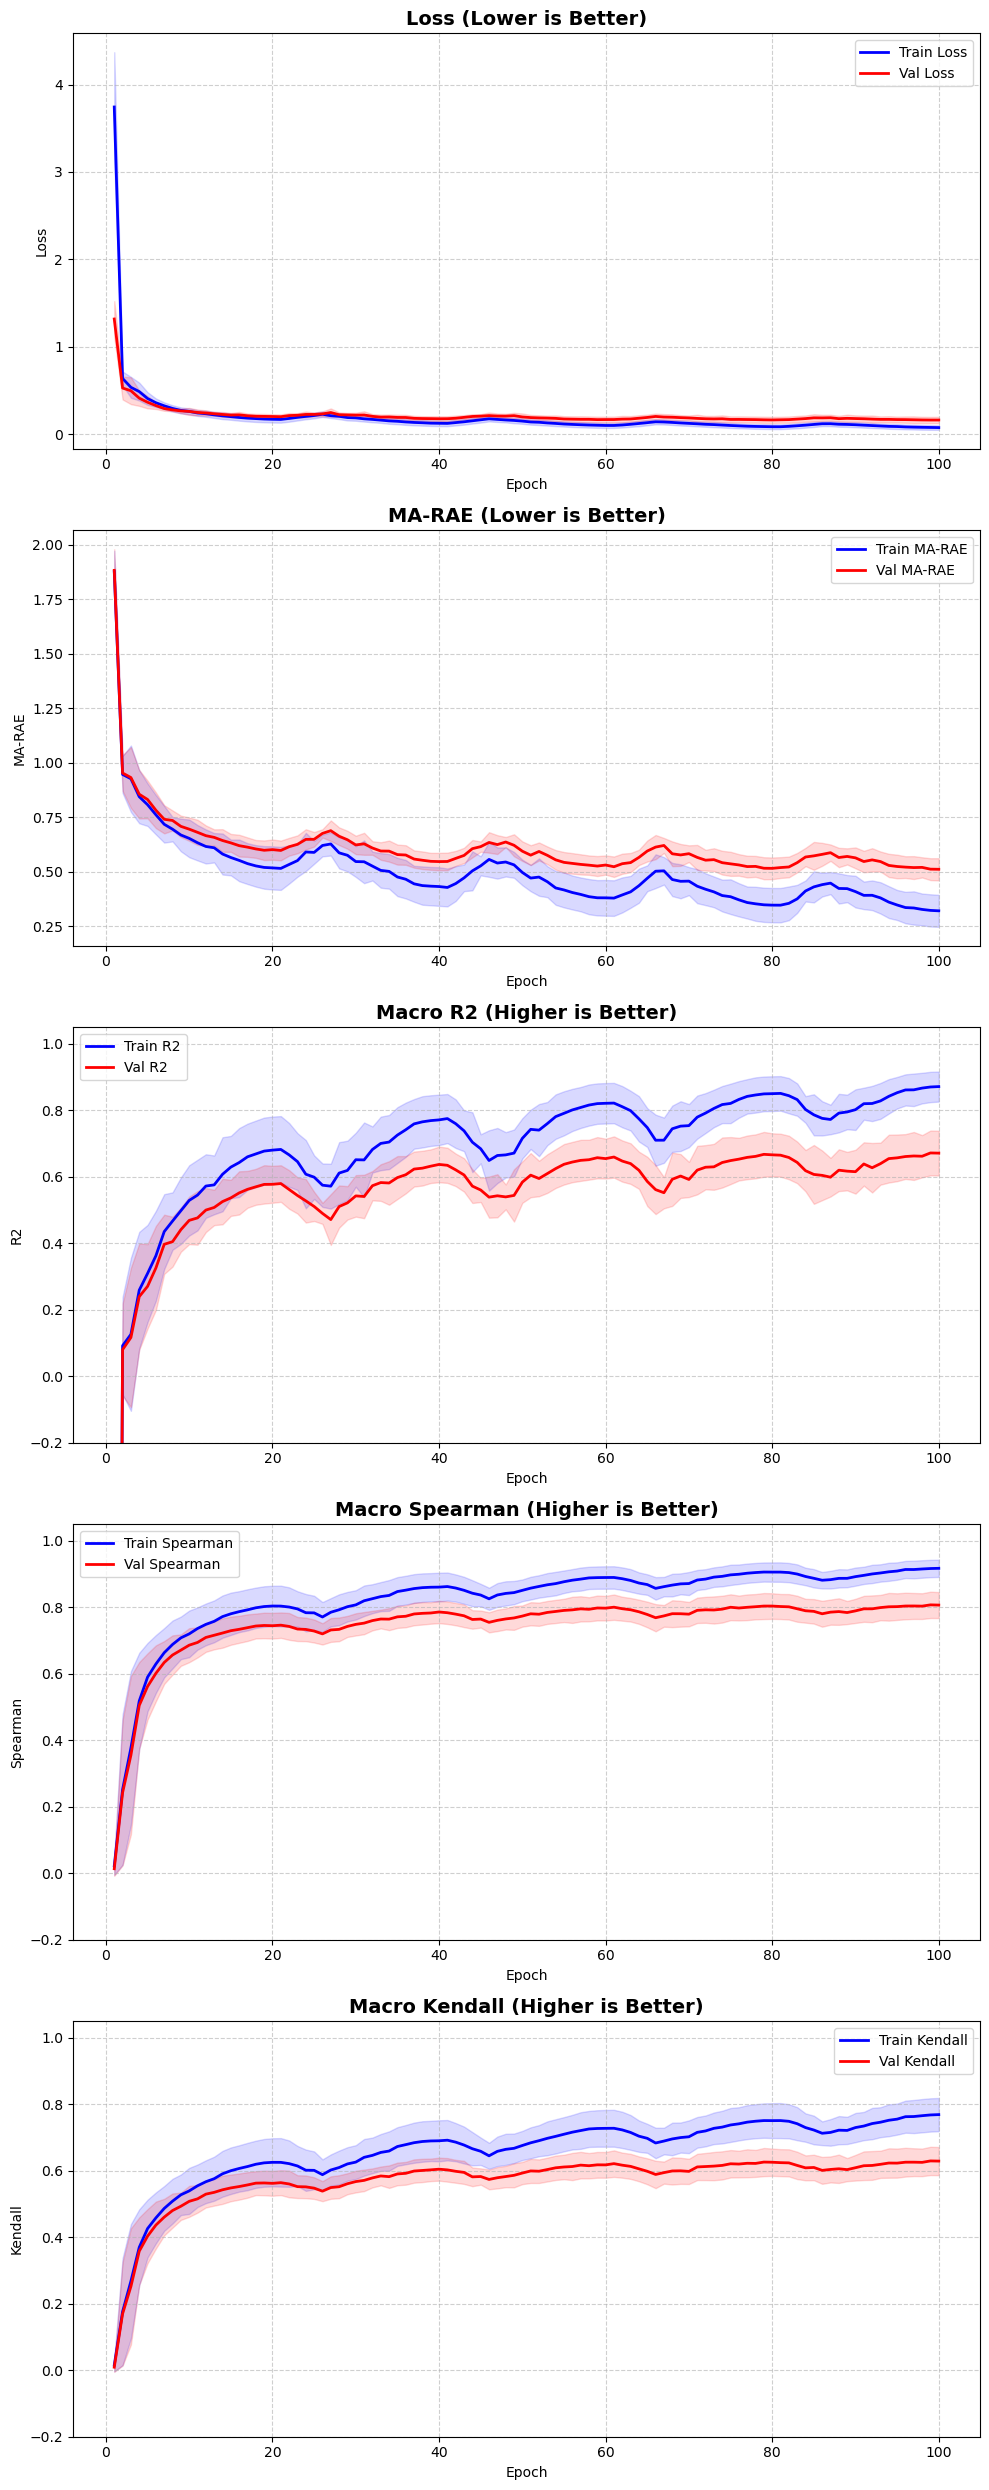

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kendalltau, spearmanr
from sklearn.metrics import r2_score

# =========================================================================
# 5. Visualization: K-Fold Re-training & Metric Tracking
# =========================================================================

def calculate_metrics_for_graph(pred_matrix, true_matrix):
    """그래프 시각화를 위한 4대 지표 계산 (Loss는 별도 계산)"""
    nan_mask = ~np.isnan(true_matrix)
    
    # 1. MA-RAE
    ma_rae = calculate_ma_rae(pred_matrix, true_matrix, nan_mask)
    
    r2s, spearmans, kendalls = [], [], []
    
    # Task별 Loop
    for i in range(true_matrix.shape[1]):
        t = true_matrix[nan_mask[:, i], i]
        p = pred_matrix[nan_mask[:, i], i]
        
        if len(t) > 1:
            # R2
            r2s.append(r2_score(t, p))
            
            # Correlation (Std가 0이면 계산 불가 -> 0 처리)
            if np.std(t) < 1e-6 or np.std(p) < 1e-6:
                spearmans.append(0.0)
                kendalls.append(0.0)
            else:
                spearmans.append(spearmanr(t, p)[0])
                kendalls.append(kendalltau(t, p)[0])
    
    return {
        'MA-RAE': ma_rae,
        'R2': np.mean(r2s) if r2s else 0.0,
        'Spearman': np.mean(spearmans) if spearmans else 0.0,
        'Kendall': np.mean(kendalls) if kendalls else 0.0
    }

def run_baseline_visualization_loop(data, params, epochs=100):
    """
    Optuna Best Params를 사용하여 K-Fold 재학습 및 History 수집
    """
    # Baseline Model의 K-Fold는 Optuna 함수 내에서 일반 KFold를 사용했으므로 동일하게 설정
    kf = KFold(n_splits=5, shuffle=True, random_state=seed)
    
    # 기록 저장소
    metrics_names = ['Loss', 'MA-RAE', 'R2', 'Spearman', 'Kendall']
    history = {
        'Train': {m: [] for m in metrics_names},
        'Val':   {m: [] for m in metrics_names}
    }
    
    print(f"\n🚀 Starting Visualization Re-training (Epochs: {epochs})...")
    
    for fold, (train_idx, val_idx) in enumerate(kf.split(data)):
        print(f"\n🔄 Processing Fold {fold+1}/5 ...")
        
        # Fold별 기록 임시 저장
        fold_hist = {
            'Train': {k: [] for k in history['Train']},
            'Val':   {k: [] for k in history['Val']}
        }
        
        # DataLoader 생성
        train_subset = Subset(data, train_idx)
        val_subset = Subset(data, val_idx)
        
        train_loader = GraphDataLoader(train_subset, batch_size=params['batch_size'], shuffle=True, drop_last=True, collate_fn=collate)
        # Train Curve용 평가 로더 (Shuffle=False) -> 정확한 지표 계산용
        train_eval_loader = GraphDataLoader(train_subset, batch_size=params['batch_size'], shuffle=False, drop_last=False, collate_fn=collate)
        val_loader = GraphDataLoader(val_subset, batch_size=params['batch_size'], shuffle=False, drop_last=False, collate_fn=collate)
        
        # 모델 초기화 (Baseline Model: GatedGCN_MultiReg)
        model = GatedGCN_MultiReg(
            in_dim=61, 
            emb_dim=params['hidden_dim'], 
            edge_dim=13, 
            pose_dim=20, 
            num_layers=params['num_layer'], 
            dropout=params['dropout'], 
            num_outputs=NUM_OUTPUTS
        ).to(device)
        
        # Optimizer & Scheduler (Optuna 함수와 동일 설정)
        optimizer = AdamW(model.parameters(), lr=1e-5)
        scheduler = CosineAnnealingWarmUpRestarts(optimizer, T_0=20, T_mult=1, eta_max=1e-3, T_up=5, gamma=0.9)
        
        # Epoch Loop
        for epoch in tqdm(range(epochs), desc=f"Fold {fold+1}"):
            # 1. Train Step
            train_loss = run_train_epoch(model, train_loader, optimizer, scheduler, device=device, task='reg')
            
            # 2. Evaluation Step (Train & Val)
            # Train 전체에 대해 평가 (시간이 좀 걸리지만 그래프를 위해 필요)
            _, t_true_list, t_pred_list = run_eval_epoch(model, train_eval_loader, device=device, task='reg')
            val_loss, v_true_list, v_pred_list = run_eval_epoch(model, val_loader, device=device, task='reg')
            
            # Numpy 변환
            t_true = np.array(t_true_list).reshape(-1, NUM_OUTPUTS)
            t_pred = np.array(t_pred_list).reshape(-1, NUM_OUTPUTS)
            v_true = np.array(v_true_list).reshape(-1, NUM_OUTPUTS)
            v_pred = np.array(v_pred_list).reshape(-1, NUM_OUTPUTS)
            
            # 3. Metric Calculation
            t_metrics = calculate_metrics_for_graph(t_pred, t_true)
            v_metrics = calculate_metrics_for_graph(v_pred, v_true)
            
            # Loss 추가
            t_metrics['Loss'] = train_loss
            v_metrics['Loss'] = val_loss
            
            # 기록
            for k in fold_hist['Train']:
                fold_hist['Train'][k].append(t_metrics[k])
                fold_hist['Val'][k].append(v_metrics[k])
        
        # Fold 종료 후 전체 History에 병합
        for mode in ['Train', 'Val']:
            for k in history[mode]:
                history[mode][k].append(fold_hist[mode][k])
                
    return history

def plot_baseline_history(history):
    """5-Fold 평균 및 표준편차 그래프 그리기"""
    metrics = ['Loss', 'MA-RAE', 'R2', 'Spearman', 'Kendall']
    titles = [
        'Loss (Lower is Better)', 
        'MA-RAE (Lower is Better)', 
        'Macro R2 (Higher is Better)', 
        'Macro Spearman (Higher is Better)', 
        'Macro Kendall (Higher is Better)'
    ]
    
    # 5행 1열 배치
    fig, axes = plt.subplots(5, 1, figsize=(10, 25))
    if len(metrics) == 1: axes = [axes]
    
    # Epoch 수 자동 감지
    epochs_len = len(history['Train']['Loss'][0])
    x_axis = range(1, epochs_len + 1)
    
    for i, metric in enumerate(metrics):
        ax = axes[i]
        
        # Data Shape: (Fold, Epoch)
        t_data = np.array(history['Train'][metric])
        v_data = np.array(history['Val'][metric])
        
        # Mean & Std
        t_mean = np.mean(t_data, axis=0)
        t_std = np.std(t_data, axis=0)
        v_mean = np.mean(v_data, axis=0)
        v_std = np.std(v_data, axis=0)
        
        # Train Plot (Blue)
        ax.plot(x_axis, t_mean, label=f'Train {metric}', color='blue', linewidth=2)
        ax.fill_between(x_axis, t_mean - t_std, t_mean + t_std, color='blue', alpha=0.15)
        
        # Val Plot (Red)
        ax.plot(x_axis, v_mean, label=f'Val {metric}', color='red', linewidth=2)
        ax.fill_between(x_axis, v_mean - v_std, v_mean + v_std, color='red', alpha=0.15)
        
        ax.set_title(titles[i], fontsize=14, fontweight='bold')
        ax.set_ylabel(metric)
        ax.set_xlabel('Epoch')
        ax.legend(loc='best')
        ax.grid(True, linestyle='--', alpha=0.6)
        
        # Y축 범위 조정 (상관계수 등)
        if metric in ['R2', 'Spearman', 'Kendall']:
            ax.set_ylim(-0.2, 1.05)
            
    plt.tight_layout()
    plt.show()

# --- 실행부 ---

# 1. Optuna Best Params 자동 가져오기
print("\n✅ Retrieving Best Params for Visualization...")
best_params_viz = multi_reg_study.best_trial.params
print(f"Params: {best_params_viz}")

# 2. 재학습 및 데이터 수집 (Epochs는 그래프 x축 길이, 예: 100)
# 주의: multi_reg_data 변수가 메모리에 있어야 합니다.
baseline_history = run_baseline_visualization_loop(multi_reg_data, best_params_viz, epochs=100)

# 3. 그래프 출력
plot_baseline_history(baseline_history)

In [ ]:
#best_params = {'hidden_dim': 256, 'dropout': 0.1, 'num_layer': 9, 'batch_size': 128} 1차시도 67등 0.76
#best_params = {'hidden_dim': 256, 'dropout': 0.1, 'num_layer': 10, 'batch_size': 32} #2차 시도(only ecfp 사용) 31등 0.69
best_params = {'hidden_dim': 256, 'dropout': 0.1, 'num_layer': 11, 'batch_size': 64} #2차 시도(only ecfp 사용) 31등 0.69
#best_params = {'hidden_dim': 256, 'dropout': 0.1, 'num_layer': 5, 'batch_size': 32} #8차 시도(only gnn사용) 성능비교

# 모델 초기화
best_emb_dim = best_params['hidden_dim']
best_num_layer = best_params['num_layer']
best_dropout = best_params['dropout']
final_model = GatedGCN_MultiReg(61, best_emb_dim, 13, 20, best_num_layer, dropout=best_dropout, num_outputs=NUM_OUTPUTS).to(device)

def count_parameters(model):
    """모델의 학습 가능한 (Trainable) 파라미터 총 개수를 반환합니다."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def print_model_summary_info(model, best_params):
    """ 최적 파라미터를 기반으로 모델의 주요 차원 흐름을 출력하고 파라미터 수를 포함합니다. """
    
    hidden_dim = best_params['hidden_dim']
    num_layer = best_params['num_layer']
    batch_size = best_params.get('batch_size', 'N/A')
    
    total_params = count_parameters(model)
    
    print("\n" + "="*80)
    print("           ⭐ GatedGCN-MultiReg Model Architecture Summary ⭐")
    print("="*80)
    print(f"1. OPTIMIZED HYPERPARAMETERS:")
    print(f"   - Hidden Dimension (Embedding Size): {hidden_dim} D")
    print(f"   - GNN Layers (Depth): {num_layer}")
    print(f"   - Dropout Rate: {best_params['dropout']}")
    print(f"   - Batch Size (Training): {batch_size}")
    
    print("\n2. FEATURE ENCODING & DIMENSIONS:")
    print(f"   - Graph Node Feature Input Size (in_dim): 61 D")
    print(f"   - GNN Position Encoding Input Size: 20 D")
    print(f"   - GNN Edge Feature Input Size: 13 D")
    
    print("\n3. ARCHITECTURE FLOW:")
    print(f"   - GNN Layers Output (h, p, e): {num_layer} layers of {hidden_dim} D")
    print(f"   - FP MLPs (Projection to {hidden_dim} D): ECFP(1024D), Avalon(1024D), MACCS(167D)")
    
    print("\n4. FUSION & READOUT:")
    print(f"   - Total Streams to Concatenate: 4 (GNN Pool + 3 FPs)")
    print(f"   - Fusion Input Size (Gating/Readout): 4 * {hidden_dim} D = {4 * hidden_dim} D")
    print(f"   - Gating Mechanism: Softmax (4 Gates)")
    print(f"   - Final Output Size: {NUM_OUTPUTS} D (9 ADMET Properties)")
    
    print("\n5. MODEL COMPLEXITY:")
    print(f"   - Total Trainable Parameters: {total_params:,} 개")
    print("="*80 + "\n")


# ★★★ 모델 요약 출력 실행 ★★★
print_model_summary_info(final_model, best_params)

# --- 테스트 데이터 로드 및 전처리 ---
log_test_df = test_df[["SMILES", "Molecule Name"]].copy()
print("테스트 데이터에 NaN 레이블 컬럼 추가 중...")
for col_name in MULTI_REG_LABEL_COLS:
    log_test_df[col_name] = np.nan

test_data = MoleculeDataset(log_test_df.reset_index(drop=True), label_cols=MULTI_REG_LABEL_COLS)
test_loader = GraphDataLoader(test_data, batch_size=best_params['batch_size'], shuffle=False, collate_fn=collate)

# --- 최종 모델 학습 (100 Epoch) ---
optimizer = AdamW(final_model.parameters(), lr=1e-5)
scheduler = CosineAnnealingWarmUpRestarts(optimizer, T_0=20, T_mult=1, eta_max=1e-3, T_up=5, gamma=0.9)

num_epochs = MAX_FINAL_EPOCHS

print(f"⭐ 최종 모델 학습 시작 (Epochs: {num_epochs})")
for epoch in tqdm(range(num_epochs), desc="Final Training"):
    run_train_epoch(final_model, GraphDataLoader(multi_reg_data, batch_size=best_params['batch_size'], shuffle=True, collate_fn=collate), optimizer, scheduler, device=device, task='reg')

# --- 최종 예측 ---
final_model.eval()
test_predictions = []
test_gates = []

with torch.no_grad():
    for g, _, fps in tqdm(test_loader, desc="Predicting Test Data"):
        g = g.to(device)
        fp1, fp2, fp3 = [fp.to(device) for fp in fps]
        outputs, gates = final_model(g, fp1, fp2, fp3)
        test_predictions.extend(outputs.cpu().numpy())
        test_gates.extend(gates.cpu().numpy())

test_predictions = np.array(test_predictions)
submission_df = pd.DataFrame(test_predictions, columns=MULTI_REG_LABEL_COLS)

# SMILES 컬럼을 추가
submission_df['SMILES'] = log_test_df['SMILES']
submission_df = submission_df[['SMILES'] + MULTI_REG_LABEL_COLS]

# ★★★ Gates 분석 및 출력 ★★★
test_gates_array = np.array(test_gates)

print("\n" + "="*50)
print("       ✅ 동적 가중치 (Gates) 평균 분석 ✅")
print("="*50)

# 평균 가중치 분석 (GNN h, FP1, FP2, FP3 순서)
mean_gates = np.mean(test_gates_array, axis=0)
gate_names = ['GNN_Pool', 'FP1_ECFP', 'FP2_Avalon', 'FP3_MACCS']
mean_gate_dict = dict(zip(gate_names, mean_gates))

print("\n전체 테스트셋 평균 가중치:")
analysis_table(mean_gate_dict)

# --- 클리핑 규칙 정의 (Original Scale) ---

# 훈련 데이터의 Max 값과 물리적 제약을 고려하여 조정된 최종 클리핑 규칙
CLIPPING_RULES = {
    'LogD': (-5.0, 8.0),
    'KSOL': (0.0, 11000.0), # 물리적 Min 0.0
    'HLM CLint': (0.0, 3000.0), # 물리적 Min 0.0
    'MLM CLint': (0.0, 11000.0), # 물리적 Min 0.0
    'Caco-2 Permeability Papp A>B': (0.0, 100.0), # 물리적 Min 0.0
    'Caco-2 Permeability Efflux': (1.0, 110.0), # 물리적 Min 1.0 (유출 비율)
    'MPPB': (0.0, 100.0), # Max 100%
    'MBPB': (0.0, 100.0), # Max 100%
    'MGMB': (0.0, 100.0), # Max 100%
}


# --- 최종 제출 파일 저장 (역변환 및 클리핑 포함) ---

# 🟢 핵심 수정: LogD의 Log_Scale=False인 경우, 10**log_pred 변환을 건너뛰도록 수정 + 클리핑 적용
def inverse_transform_admet_and_clip(submission_df, conversion_dict, clipping_rules):
    output_df = submission_df.copy()
    original_assay_cols = list(conversion_dict.keys())
    
    for assay_name, rules in conversion_dict.items():
        log_scale, multiplier, log_name = rules
        log_pred = output_df[log_name].values
        
        # --- 1. 역변환 공식 적용 ---
        if log_scale == False:
            original_value = log_pred
        else:
            intermediate_value = 10**log_pred
            intermediate_value = intermediate_value / multiplier
            original_value = intermediate_value - 1.0
        # ------------------------
        
        # 2. 원본 스케일 값 저장
        output_df[assay_name] = original_value
        
        # 3. 📐 생물물리학적 클리핑 적용
        if assay_name in clipping_rules:
            min_val, max_val = clipping_rules[assay_name]
            
            # 클리핑 적용: 물리적 제약 이탈을 교정
            output_df[assay_name] = output_df[assay_name].clip(lower=min_val, upper=max_val)
            
    # 4. 불필요한 Log 컬럼 삭제 및 SMILES + 원본 컬럼만 남기기
    columns_to_keep = ['SMILES'] + original_assay_cols
    output_df = output_df[columns_to_keep].copy()
    
    return output_df

print("역변환 (Log-scale -> Original-scale) 및 클리핑 적용 중...")
final_submission_df = inverse_transform_admet_and_clip(submission_df, conversion_dict, CLIPPING_RULES)

# 컬럼 순서를 맞춥니다.
original_assay_cols = list(conversion_dict.keys())
columns_for_output = ['SMILES'] + original_assay_cols

final_submission_df = final_submission_df[columns_for_output]

# 클리핑이 적용되었음을 명시하기 위해 파일 이름을 변경했습니다.
final_submission_df.to_csv('baseline_mseloss_gated_mlp3.csv', index=False)

print("\n✅ 최종 제출 파일 'baseline_mseloss_gated_mlp3.csv' (원본 스케일, 클리핑 적용) 저장 완료.")